# Import

In [61]:
import os
import time

from torchvision import datasets, transforms
import torchvision.models as models

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

from matplotlib import pyplot as plt

In [62]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

# Load Data

In [63]:
image_rotation = 10
image_jitter_brightness = 0.2
image_jitter_contrast = 0.2

image_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(image_rotation),
    transforms.ColorJitter(brightness=image_jitter_brightness, contrast=image_jitter_contrast),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # from ImageNet Dataset as later Transfer Learning will be used
])

In [64]:
dataset_path = "./dataset"

dataset = datasets.ImageFolder(root=dataset_path, transform=image_transforms)
len(dataset)

2300

In [85]:
class_names = dataset.classes

In [66]:
num_classes = len(dataset.classes)
num_classes

6

In [67]:
train_pct = 0.75
train_size = int(train_pct*len(dataset))

val_size = len(dataset) - train_size

train_size, val_size

(1725, 575)

In [68]:
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [69]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

train_loader, val_loader

(<torch.utils.data.dataloader.DataLoader at 0x19efda12fe0>,
 <torch.utils.data.dataloader.DataLoader at 0x19efda13f40>)

In [70]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [71]:
sample_image = 2

In [72]:
labels[sample_image]

tensor(2)

In [73]:
images[sample_image].shape

torch.Size([3, 224, 224])

In [74]:
images[sample_image].permute(1,2,0).shape

torch.Size([224, 224, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


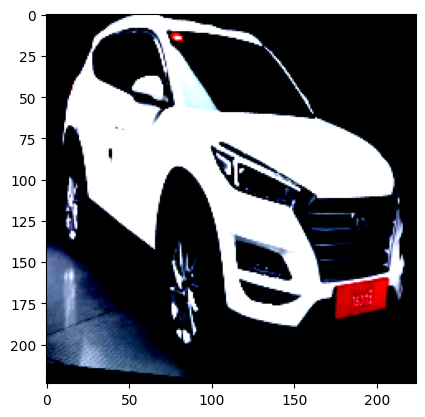

In [75]:
plt.imshow(images[sample_image].permute(1,2,0))
plt.show()

# Model Training

## Model 1 : CNN

In [76]:
class CarClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential( # (3, 224, 224)
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3,3), stride=1, padding=1), # (16, 224, 224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=2, padding=0),  # (16, 112, 112) 
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3,3), stride=1, padding=1), # (32, 112, 112)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=2, padding=0),  # (32, 56, 56)  
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3,3), stride=1, padding=1), # (64, 56, 56)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=2, padding=0),  # (64, 28, 28) 
            nn.Flatten(), # (64 x 28 x 28)
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )
    
    def forward(self, x):
        x = self.network(x)
        return x

In [77]:
# Instantiate the model, loss function, and optimizer
learning_rate = 0.001

model = CarClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [82]:
def train_model(model, criterion, optimizer, epochs=5):
    start = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            # zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # backward pass and optimization
            loss.backward()
            optimizer.step()
            
            if(batch_num % 10 == 0):
                print(f"Batch: {batch_num+1}, Epoch: {epoch+1}, Loss: {loss.item():0.2f}")
            
            # running loss
            running_loss += loss.item() * images.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch: [{epoch+1}/{epochs}], Avg loss: {epoch_loss:.4f}")
    
        # Validation
        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_predictions = []
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())
                
            print(f"*** Validation Accuracy: {100 * correct / total:.2f}% ***")
    
    end = time.time()
    print(f"Execution Time: {end - start} seconds")
    
    return all_labels, all_predictions

In [48]:
all_labels, all_predictions = train_model(model, criterion, optimizer, epochs=5)

Batch: 1, Epoch: 1, Loss: 0.77
Batch: 11, Epoch: 1, Loss: 1.24
Batch: 21, Epoch: 1, Loss: 0.96
Batch: 31, Epoch: 1, Loss: 0.91
Batch: 41, Epoch: 1, Loss: 0.84
Batch: 51, Epoch: 1, Loss: 0.95
Epoch: [1/5], Avg loss: 1.0006
*** Validation Accuracy: 51.30% ***
Batch: 1, Epoch: 2, Loss: 0.88
Batch: 11, Epoch: 2, Loss: 0.96
Batch: 21, Epoch: 2, Loss: 0.95
Batch: 31, Epoch: 2, Loss: 0.90
Batch: 41, Epoch: 2, Loss: 0.79
Batch: 51, Epoch: 2, Loss: 0.77
Epoch: [2/5], Avg loss: 0.9329
*** Validation Accuracy: 51.13% ***
Batch: 1, Epoch: 3, Loss: 0.76
Batch: 11, Epoch: 3, Loss: 1.18
Batch: 21, Epoch: 3, Loss: 1.00
Batch: 31, Epoch: 3, Loss: 0.76
Batch: 41, Epoch: 3, Loss: 0.67
Batch: 51, Epoch: 3, Loss: 1.26
Epoch: [3/5], Avg loss: 0.8901
*** Validation Accuracy: 52.35% ***
Batch: 1, Epoch: 4, Loss: 1.06
Batch: 11, Epoch: 4, Loss: 0.75
Batch: 21, Epoch: 4, Loss: 0.75
Batch: 31, Epoch: 4, Loss: 0.82
Batch: 41, Epoch: 4, Loss: 0.89
Batch: 51, Epoch: 4, Loss: 0.99
Epoch: [4/5], Avg loss: 0.8597
*** 

## Model 2 : CNN with Regularization

In [49]:
class CarClassifierCNNWithRegularization(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential( # (3, 224, 224)
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3,3), stride=1, padding=1), # (16, 224, 224)
            nn.BatchNorm2d(num_features=16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=2, padding=0),  # (16, 112, 112) 
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3,3), stride=1, padding=1), # (32, 112, 112)
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=2, padding=0),  # (32, 56, 56)  
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3,3), stride=1, padding=1), # (64, 56, 56)
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=2, padding=0),  # (64, 28, 28) 
            nn.Flatten(), # (64 x 28 x 28)
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )
    
    def forward(self, x):
        x = self.network(x)
        return x

In [50]:
# Instantiate the model, loss function, and optimizer
learning_rate = 0.001
weight_decay = 1e-4

model = CarClassifierCNNWithRegularization(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

In [51]:
cnn_with_regularization_all_labels, cnn_with_regularization_all_predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 1, Epoch: 1, Loss: 1.82
Batch: 11, Epoch: 1, Loss: 4.90
Batch: 21, Epoch: 1, Loss: 2.62
Batch: 31, Epoch: 1, Loss: 2.01
Batch: 41, Epoch: 1, Loss: 1.74
Batch: 51, Epoch: 1, Loss: 1.76
Epoch: [1/10], Avg loss: 2.9873
*** Validation Accuracy: 34.26% ***
Batch: 1, Epoch: 2, Loss: 1.48
Batch: 11, Epoch: 2, Loss: 1.39
Batch: 21, Epoch: 2, Loss: 1.59
Batch: 31, Epoch: 2, Loss: 1.51
Batch: 41, Epoch: 2, Loss: 1.30
Batch: 51, Epoch: 2, Loss: 1.35
Epoch: [2/10], Avg loss: 1.5679
*** Validation Accuracy: 44.35% ***
Batch: 1, Epoch: 3, Loss: 1.66
Batch: 11, Epoch: 3, Loss: 1.56
Batch: 21, Epoch: 3, Loss: 1.57
Batch: 31, Epoch: 3, Loss: 1.51
Batch: 41, Epoch: 3, Loss: 1.29
Batch: 51, Epoch: 3, Loss: 1.68
Epoch: [3/10], Avg loss: 1.4096
*** Validation Accuracy: 50.61% ***
Batch: 1, Epoch: 4, Loss: 1.17
Batch: 11, Epoch: 4, Loss: 1.44
Batch: 21, Epoch: 4, Loss: 1.46
Batch: 31, Epoch: 4, Loss: 1.15
Batch: 41, Epoch: 4, Loss: 1.02
Batch: 51, Epoch: 4, Loss: 1.31
Epoch: [4/10], Avg loss: 1.3234


## Model 3 : Transfer Learning EfficientNet

In [53]:
class CarClassifierEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(weights='DEFAULT')
        
        for param in self.model.parameters():
            param.requires_grad = False
        
        in_features = self.model.classifier[1].in_features
        
        self.model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features=in_features, out_features=num_classes)
        )
    
    def forward(self, x):
        x = self.model(x)
        return x

In [54]:
# Instantiate the model, loss function, and optimizer
learning_rate = 0.001

model = CarClassifierEfficientNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p : p.requires_grad, model.parameters()), lr=learning_rate)

In [55]:
model_transfer_all_labels, model_transfer_all_predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 1, Epoch: 1, Loss: 1.78
Batch: 11, Epoch: 1, Loss: 1.57
Batch: 21, Epoch: 1, Loss: 1.49
Batch: 31, Epoch: 1, Loss: 1.42
Batch: 41, Epoch: 1, Loss: 1.35
Batch: 51, Epoch: 1, Loss: 1.27
Epoch: [1/10], Avg loss: 1.4833
*** Validation Accuracy: 57.04% ***
Batch: 1, Epoch: 2, Loss: 1.36
Batch: 11, Epoch: 2, Loss: 1.30
Batch: 21, Epoch: 2, Loss: 1.14
Batch: 31, Epoch: 2, Loss: 1.13
Batch: 41, Epoch: 2, Loss: 1.10
Batch: 51, Epoch: 2, Loss: 1.01
Epoch: [2/10], Avg loss: 1.1316
*** Validation Accuracy: 61.57% ***
Batch: 1, Epoch: 3, Loss: 0.92
Batch: 11, Epoch: 3, Loss: 1.15
Batch: 21, Epoch: 3, Loss: 0.89
Batch: 31, Epoch: 3, Loss: 0.88
Batch: 41, Epoch: 3, Loss: 1.02
Batch: 51, Epoch: 3, Loss: 0.82
Epoch: [3/10], Avg loss: 1.0165
*** Validation Accuracy: 62.78% ***
Batch: 1, Epoch: 4, Loss: 0.80
Batch: 11, Epoch: 4, Loss: 0.71
Batch: 21, Epoch: 4, Loss: 1.15
Batch: 31, Epoch: 4, Loss: 1.15
Batch: 41, Epoch: 4, Loss: 0.97
Batch: 51, Epoch: 4, Loss: 1.00
Epoch: [4/10], Avg loss: 0.9448


## Model 4 : Transfer Learning ResNet

In [58]:
class CarClassifierResNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')
        
        # Freeze all layers except last fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
        
        # Unfreeze layer4
        for param in self.model.layer4.parameters():
            param.requires_grad = True
        
        # Replace the fully connected layer
        
        in_features = self.model.fc.in_features
        
        self.model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features=in_features, out_features=num_classes)
        )
    
    def forward(self, x):
        x = self.model(x)
        return x

In [59]:
# Instantiate the model, loss function, and optimizer
learning_rate = 0.001

model = CarClassifierResNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p : p.requires_grad, model.parameters()), lr=learning_rate)

In [60]:
labels, predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 1, Epoch: 1, Loss: 1.83
Batch: 11, Epoch: 1, Loss: 1.09
Batch: 21, Epoch: 1, Loss: 1.01
Batch: 31, Epoch: 1, Loss: 0.57
Batch: 41, Epoch: 1, Loss: 0.90
Batch: 51, Epoch: 1, Loss: 0.66
Epoch: [1/10], Avg loss: 0.9059
*** Validation Accuracy: 73.57% ***
Batch: 1, Epoch: 2, Loss: 0.34
Batch: 11, Epoch: 2, Loss: 0.43
Batch: 21, Epoch: 2, Loss: 0.34
Batch: 31, Epoch: 2, Loss: 0.30
Batch: 41, Epoch: 2, Loss: 0.58
Batch: 51, Epoch: 2, Loss: 0.47
Epoch: [2/10], Avg loss: 0.4642
*** Validation Accuracy: 76.17% ***
Batch: 1, Epoch: 3, Loss: 0.30
Batch: 11, Epoch: 3, Loss: 0.51
Batch: 21, Epoch: 3, Loss: 0.46
Batch: 31, Epoch: 3, Loss: 0.37
Batch: 41, Epoch: 3, Loss: 0.25
Batch: 51, Epoch: 3, Loss: 0.33
Epoch: [3/10], Avg loss: 0.3512
*** Validation Accuracy: 80.17% ***
Batch: 1, Epoch: 4, Loss: 0.23
Batch: 11, Epoch: 4, Loss: 0.19
Batch: 21, Epoch: 4, Loss: 0.15
Batch: 31, Epoch: 4, Loss: 0.47
Batch: 41, Epoch: 4, Loss: 0.22
Batch: 51, Epoch: 4, Loss: 0.25
Epoch: [4/10], Avg loss: 0.2301


I ran hyperparameter tuning with Optuna, and discovered that best parameters for ResNet model is (1) learning_rate = 0.0005, (2) dropout_rate = 0.3

## Model 5 : Transfer Learning ResNet and Tuning

In [79]:
class CarClassifierResNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')
        
        # Freeze all layers except last fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
        
        # Unfreeze layer4
        for param in self.model.layer4.parameters():
            param.requires_grad = True
        
        # Replace the fully connected layer
        
        in_features = self.model.fc.in_features
        
        self.model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features=in_features, out_features=num_classes)
        )
    
    def forward(self, x):
        x = self.model(x)
        return x

In [83]:
# Instantiate the model, loss function, and optimizer
learning_rate = 0.0005

model = CarClassifierResNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p : p.requires_grad, model.parameters()), lr=learning_rate)

labels, predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 1, Epoch: 1, Loss: 1.80
Batch: 11, Epoch: 1, Loss: 1.13
Batch: 21, Epoch: 1, Loss: 0.77
Batch: 31, Epoch: 1, Loss: 0.57
Batch: 41, Epoch: 1, Loss: 0.54
Batch: 51, Epoch: 1, Loss: 0.57
Epoch: [1/10], Avg loss: 0.9300
*** Validation Accuracy: 74.96% ***
Batch: 1, Epoch: 2, Loss: 0.45
Batch: 11, Epoch: 2, Loss: 0.52
Batch: 21, Epoch: 2, Loss: 0.48
Batch: 31, Epoch: 2, Loss: 0.42
Batch: 41, Epoch: 2, Loss: 0.49
Batch: 51, Epoch: 2, Loss: 0.60
Epoch: [2/10], Avg loss: 0.4600
*** Validation Accuracy: 78.09% ***
Batch: 1, Epoch: 3, Loss: 0.13
Batch: 11, Epoch: 3, Loss: 0.23
Batch: 21, Epoch: 3, Loss: 0.16
Batch: 31, Epoch: 3, Loss: 0.43
Batch: 41, Epoch: 3, Loss: 0.49
Batch: 51, Epoch: 3, Loss: 0.34
Epoch: [3/10], Avg loss: 0.3166
*** Validation Accuracy: 77.22% ***
Batch: 1, Epoch: 4, Loss: 0.08
Batch: 11, Epoch: 4, Loss: 0.30
Batch: 21, Epoch: 4, Loss: 0.10
Batch: 31, Epoch: 4, Loss: 0.12
Batch: 41, Epoch: 4, Loss: 0.41
Batch: 51, Epoch: 4, Loss: 0.35
Epoch: [4/10], Avg loss: 0.2133


In [84]:
from sklearn.metrics import classification_report

report = classification_report(labels, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.89      0.81      0.85       121
           1       0.71      0.76      0.73        88
           2       0.87      0.90      0.88       132
           3       0.93      0.54      0.68        76
           4       0.64      0.93      0.76        84
           5       0.90      0.82      0.86        74

    accuracy                           0.81       575
   macro avg       0.82      0.79      0.79       575
weighted avg       0.83      0.81      0.81       575



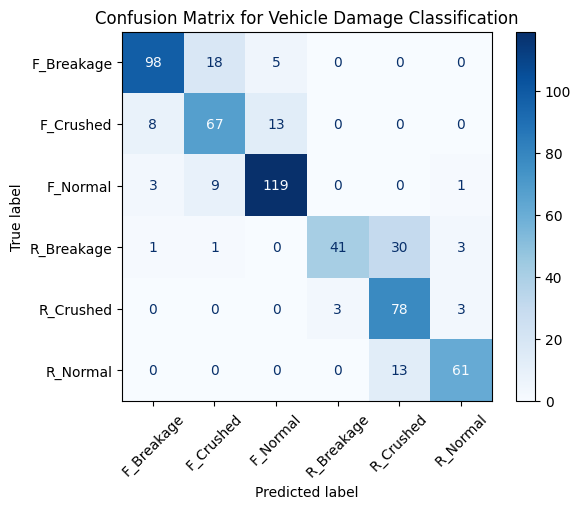

In [86]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

conf_matrix = confusion_matrix(labels, predictions, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()

# Save the model

In [88]:
torch.save(model.state_dict(), 'saved_model.pth')